# Краевая задача для стационарных структур в системе «брюсселятора»

В работе исследуется нелинейная краевая задача
\
$$u'' + \frac{1}{D_u} f(u,v)=0,\qquad
v'' + \frac{1}{D_v} g(u,v)=0,$$
\
где
\
$$f(u,v)=A-(B+1)u+u^2v,\qquad
g(u,v)=Bu-u^2v,$$
\
\
$$D_u=0.0016,\qquad D_v=0.008,\qquad A=2,\qquad B=4.6,$$
\
с граничными условиями
\
$$u(0)=u(X)=2,\qquad v(0)=v(X)=2.3.$$


Численно исследуется зависимость решения от длины интервала $$X \in [50,200]$$

## Что сделано в ноутбуке

1. Реализован **метод стрельбы** с интегрированием **расширенной системы чувствительности**.
2. Реализован **метод квазилинеаризации** на сетке; возникающая линейная система решается **блочной прогонкой**.
3. Оба подхода адаптированы к **задаче поиска собственных значений** для линеаризованной задачи.
4. Построены:
   - интегральные кривые \(u(x), v(x)\),
   - история изменения пристрелочных параметров,
   - история итераций квазилинеаризации,
   - собственные функции для найденных собственных значений,
   - вспомогательные графики и таблицы для сравнения методов.

## Постановка и план решения

Стационарное однородное решение системы сразу находится из условий
\
$$f(u,v)=0,\qquad g(u,v)=0$$.
\
Для брюсселятора это равновесие равно
\
$$u_* = A = 2,\qquad v_* = \frac{B}{A} = 2.3$$.


Дальнейшая логика работы такая:

- сначала строится и анализируется **линеаризованная спектральная задача**;
- затем на её основе выбираются хорошие начальные приближения;
- после этого нелинейная краевая задача решается:
  - методом стрельбы,
  - методом квазилинеаризации.

Для метода стрельбы в нелинейной задаче используется естественная для симметричных структур постановка на половине отрезка:
\
$$u_x(X/2)=0,\qquad v_x(X/2)=0$$,
\
а неизвестными параметрами стрельбы выступают значения в центре:
\
$$u(X/2),\qquad v(X/2)$$.

Это особенно удобно при одинаковых граничных условиях на концах отрезка.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
np.set_printoptions(precision=10, suppress=True)

A = 2.0
B = 4.6
Du = 0.0016
Dv = 0.008

u_eq = A
v_eq = B / A


def f_uv(u, v):
    return A - (B + 1.0) * u + u * u * v


def g_uv(u, v):
    return B * u - u * u * v


def jac_reaction(u, v):
    fu = -(B + 1.0) + 2.0 * u * v
    fv = u * u
    gu = B - 2.0 * u * v
    gv = -u * u
    return fu, fv, gu, gv


fu_eq, fv_eq, gu_eq, gv_eq = jac_reaction(u_eq, v_eq)
M_lin = np.array([
    [fu_eq / Du, fv_eq / Du],
    [gu_eq / Dv, gv_eq / Dv]
], dtype=float)

mu_raw, R_raw = np.linalg.eig(M_lin)
order = np.argsort(mu_raw.real)[::-1]
mu_exact = mu_raw.real[order]
R_exact = R_raw.real[:, order]

for j in range(R_exact.shape[1]):
    if abs(R_exact[0, j]) > 1e-14:
        R_exact[:, j] = R_exact[:, j] / R_exact[0, j]
    else:
        k = np.argmax(np.abs(R_exact[:, j]))
        R_exact[:, j] = R_exact[:, j] / R_exact[k, j]


def max_abs(a):
    if not np.all(np.isfinite(a)):
        return np.inf
    return float(np.max(np.abs(a)))


def rk4(fun, x0, x1, y0, nsteps):
    x = np.linspace(x0, x1, nsteps + 1)
    h = (x1 - x0) / nsteps
    y = np.zeros((nsteps + 1, len(y0)), dtype=float)
    y[0] = y0
    for i in range(nsteps):
        xi = x[i]
        yi = y[i]
        k1 = fun(xi, yi)
        k2 = fun(xi + 0.5 * h, yi + 0.5 * h * k1)
        k3 = fun(xi + 0.5 * h, yi + 0.5 * h * k2)
        k4 = fun(xi + h, yi + h * k3)
        y[i + 1] = yi + h * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0
    return x, y


def block_tridiagonal_solve(Ablk, Bblk, Cblk, rhs):
    n = len(Bblk)
    Cp = np.zeros_like(Cblk)
    Dp = np.zeros_like(rhs)

    M0 = Bblk[0]
    Cp[0] = np.linalg.solve(M0, Cblk[0]) if n > 1 else np.zeros((2, 2))
    Dp[0] = np.linalg.solve(M0, rhs[0])

    for i in range(1, n):
        Mi = Bblk[i] - Ablk[i] @ Cp[i - 1]
        Ri = rhs[i] - Ablk[i] @ Dp[i - 1]
        Cp[i] = np.linalg.solve(Mi, Cblk[i]) if i < n - 1 else np.zeros((2, 2))
        Dp[i] = np.linalg.solve(Mi, Ri)

    sol = np.zeros_like(rhs)
    sol[-1] = Dp[-1]
    for i in range(n - 2, -1, -1):
        sol[i] = Dp[i] - Cp[i] @ sol[i + 1]
    return sol


def critical_lengths_for_branch(branch, xmin=50.0, xmax=200.0):
    step = np.pi / np.sqrt(mu_exact[branch])
    nmin = int(np.ceil(xmin / step))
    nmax = int(np.floor(xmax / step))
    ns = np.arange(nmin, nmax + 1)
    return ns, ns * step, step


def nearest_critical_length(branch, X):
    step = np.pi / np.sqrt(mu_exact[branch])
    n = int(np.round(X / step))
    return n, n * step


def reflect_center_solution(X, s, Yhalf):
    x_full = np.concatenate([0.5 * X - s[::-1], 0.5 * X + s[1:]])
    u_half = Yhalf[:, 0]
    v_half = Yhalf[:, 2]
    u_full = np.concatenate([u_half[::-1], u_half[1:]])
    v_full = np.concatenate([v_half[::-1], v_half[1:]])
    return x_full, u_full, v_full

## Линеаризация и спектральная задача

Положим
\
$$u = u_* + \phi,\qquad v = v_* + \psi$$,
\
где \($$(u_*,v_*)=(2,2.3)$$\). Тогда в первом приближении получаем систему
\[
\phi'' + \frac{1}{D_u}\bigl(f_u^* \phi + f_v^* \psi\bigr)=0,
\qquad
\psi'' + \frac{1}{D_v}\bigl(g_u^* \phi + g_v^* \psi\bigr)=0.
\]

Если перейти к безразмерной координате \(\xi=x/X\), то на отрезке \([0,1]\) возникает спектральный параметр
\[
\lambda = X^2,
\]
и задача принимает вид
\[
y_{\xi\xi} + \lambda M y = 0,\qquad y(0)=y(1)=0,
\]
где
\[
y = \begin{pmatrix}\phi \\ \psi\end{pmatrix},\qquad
M =
\begin{pmatrix}
f_u^*/D_u & f_v^*/D_u \\
g_u^*/D_v & g_v^*/D_v
\end{pmatrix}.
\]

Если \(\mu_j\) — собственные значения матрицы \(M\), то аналитически
\[
\lambda_{j,n} = \frac{(n\pi)^2}{\mu_j},
\qquad
X_{j,n} = \sqrt{\lambda_{j,n}} = \frac{n\pi}{\sqrt{\mu_j}},
\qquad n=1,2,\dots
\]

То есть задача поиска собственных значений напрямую связана с критическими длинами \(X\), на которых возникают моды линеаризованной задачи.

Линеаризованная матрица M:
[[2250. 2500.]
 [-575. -500.]]

Ветвь 1: mu = 1548.1456008918, собственный вектор ~ [ 1.           -0.2807417596], шаг критических длин ΔX = 0.0798443098
Ветвь 2: mu = 201.8543991082, собственный вектор ~ [ 1.           -0.8192582404], шаг критических длин ΔX = 0.2211213939

Ближайшие критические длины к X = 50.0:
  ветвь 1: n = 626, X_crit ≈ 49.9825379473, |X-X_crit| = 0.0174620527
  ветвь 2: n = 226, X_crit ≈ 49.9734350189, |X-X_crit| = 0.0265649811

Ближайшие критические длины к X = 100.0:
  ветвь 1: n = 1252, X_crit ≈ 99.9650758945, |X-X_crit| = 0.0349241055
  ветвь 2: n = 452, X_crit ≈ 99.9468700379, |X-X_crit| = 0.0531299621

Ближайшие критические длины к X = 150.0:
  ветвь 1: n = 1879, X_crit ≈ 150.0274581516, |X-X_crit| = 0.0274581516
  ветвь 2: n = 678, X_crit ≈ 149.9203050568, |X-X_crit| = 0.0796949432

Ближайшие критические длины к X = 200.0:
  ветвь 1: n = 2505, X_crit ≈ 200.0099960988, |X-X_crit| = 0.0099960988
  ветвь 2: n = 904, X_crit ≈ 199.89

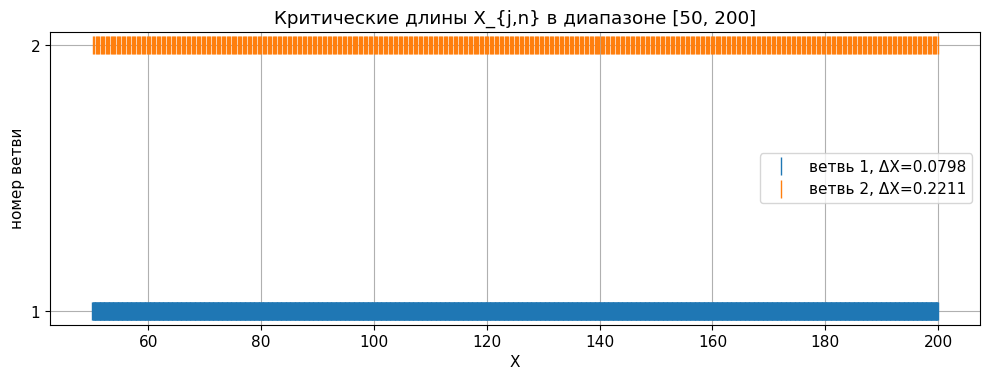

In [2]:
print("Линеаризованная матрица M:")
print(M_lin)
print()

for j in range(len(mu_exact)):
    step = np.pi / np.sqrt(mu_exact[j])
    print(f"Ветвь {j+1}: mu = {mu_exact[j]:.10f}, собственный вектор ~ {R_exact[:, j]}, шаг критических длин ΔX = {step:.10f}")
print()

probes = [50.0, 100.0, 150.0, 200.0]
for X0 in probes:
    print(f"Ближайшие критические длины к X = {X0:.1f}:")
    for j in range(len(mu_exact)):
        n, Xc = nearest_critical_length(j, X0)
        print(f"  ветвь {j+1}: n = {n}, X_crit ≈ {Xc:.10f}, |X-X_crit| = {abs(X0 - Xc):.10f}")
    print()

fig, ax = plt.subplots(figsize=(12, 3.8))
for j in range(len(mu_exact)):
    ns, Xs, step = critical_lengths_for_branch(j, 50.0, 200.0)
    ax.plot(Xs, np.full_like(Xs, j + 1, dtype=float), "|", ms=13, label=f"ветвь {j+1}, ΔX={step:.4f}")
ax.set_xlabel("X")
ax.set_ylabel("номер ветви")
ax.set_yticks([1, 2])
ax.set_title("Критические длины X_{j,n} в диапазоне [50, 200]")
ax.legend()
plt.show()

## Численный поиск собственных значений

Ниже используются два способа.

### 1. Метод стрельбы для спектральной задачи

На отрезке \([0,1]\) решается задача
\[
y'' + \lambda M y = 0,\qquad y(0)=y(1)=0.
\]

Чтобы устранить тривиальность, фиксируем нормировку
\[
\phi'(0)=1,
\]
а вторую производную параметризуем как
\[
\psi'(0)=\eta.
\]
Тогда неизвестными становятся \((\eta,\lambda)\), а на правом конце нужно выполнить
\[
\phi(1)=0,\qquad \psi(1)=0.
\]
Якобиан по параметрам вычисляется интегрированием **расширенной системы чувствительности**.

### 2. Сеточный метод с дополненным вектором

На сетке для задачи
\[
y'' + \lambda M y = 0
\]
получается блочно-трёхдиагональная система. Поскольку \(\lambda\) тоже неизвестно, добавляется условие нормировки
\[
\phi(\xi_1)=1.
\]
Ньютоновский шаг по \((Y,\lambda)\) раскладывается на два решения с одной и той же блочно-трёхдиагональной матрицей — это и есть удобная реализация метода дополненного вектора. Внутри используется **блочная прогонка**.

In [3]:
def integrate_eigen_shoot(eta, lam, nsteps=5000, with_sens=True):
    M11, M12 = M_lin[0]
    M21, M22 = M_lin[1]

    if with_sens:
        y0 = np.array([
            0.0, 1.0, 0.0, eta,
            0.0, 0.0, 0.0, 1.0,
            0.0, 0.0, 0.0, 0.0
        ], dtype=float)

        def rhs(x, Y):
            y1, p1, y2, p2 = Y[:4]
            zeta = Y[4:8]
            zlam = Y[8:12]

            Fy = np.array([
                [0.0, 1.0, 0.0, 0.0],
                [-lam * M11, 0.0, -lam * M12, 0.0],
                [0.0, 0.0, 0.0, 1.0],
                [-lam * M21, 0.0, -lam * M22, 0.0]
            ], dtype=float)

            yprime = np.array([
                p1,
                -lam * (M11 * y1 + M12 * y2),
                p2,
                -lam * (M21 * y1 + M22 * y2)
            ], dtype=float)

            flam = np.array([
                0.0,
                -(M11 * y1 + M12 * y2),
                0.0,
                -(M21 * y1 + M22 * y2)
            ], dtype=float)

            return np.concatenate([yprime, Fy @ zeta, Fy @ zlam + flam])

        xi, Y = rk4(rhs, 0.0, 1.0, y0, nsteps)
        res = np.array([Y[-1, 0], Y[-1, 2]], dtype=float)
        J = np.array([
            [Y[-1, 4], Y[-1, 8]],
            [Y[-1, 6], Y[-1, 10]]
        ], dtype=float)
        return xi, Y[:, :4], res, J

    y0 = np.array([0.0, 1.0, 0.0, eta], dtype=float)

    def rhs_plain(x, Y):
        y1, p1, y2, p2 = Y
        return np.array([
            p1,
            -lam * (M11 * y1 + M12 * y2),
            p2,
            -lam * (M21 * y1 + M22 * y2)
        ], dtype=float)

    xi, Y = rk4(rhs_plain, 0.0, 1.0, y0, nsteps)
    res = np.array([Y[-1, 0], Y[-1, 2]], dtype=float)
    return xi, Y, res


def solve_eigen_by_shooting(branch, n, eta0=None, lam0=None, nsteps=5000, tol=1e-11, maxit=20):
    lam_exact = (n * np.pi) ** 2 / mu_exact[branch]
    eta_exact = R_exact[1, branch] / R_exact[0, branch]

    if eta0 is None:
        eta0 = 0.87 * eta_exact
    if lam0 is None:
        lam0 = 1.10 * lam_exact

    params = np.array([eta0, lam0], dtype=float)
    history = []

    for it in range(maxit):
        xi, Y, res, J = integrate_eigen_shoot(params[0], params[1], nsteps=nsteps, with_sens=True)
        norm = max_abs(res)
        history.append({
            "eta": float(params[0]),
            "lambda": float(params[1]),
            "norm": float(norm)
        })

        if norm < tol:
            break

        try:
            delta = np.linalg.solve(J, -res)
        except np.linalg.LinAlgError:
            break

        accepted = False
        alpha = 1.0

        for _ in range(12):
            trial = params + alpha * delta
            if trial[1] <= 0.0:
                alpha *= 0.5
                continue
            _, _, res_trial = integrate_eigen_shoot(trial[0], trial[1], nsteps=max(2000, nsteps // 2), with_sens=False)
            if max_abs(res_trial) < norm:
                params = trial
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            params = params + 0.3 * delta
            if params[1] <= 0.0:
                params[1] = abs(params[1]) + 1e-8

    xi, Y, res, J = integrate_eigen_shoot(params[0], params[1], nsteps=nsteps, with_sens=True)
    scale = 1.0 / np.max(np.abs(Y[:, [0, 2]]))
    Yscaled = Y.copy()
    Yscaled[:, :4] *= scale

    converged = max_abs(res) < tol

    return {
        "branch": branch + 1,
        "n": n,
        "eta": float(params[0]),
        "lambda": float(params[1]),
        "lambda_exact": float(lam_exact),
        "eta_exact": float(eta_exact),
        "Xcrit": float(np.sqrt(params[1])),
        "Xcrit_exact": float(np.sqrt(lam_exact)),
        "xi": xi,
        "phi_u": Yscaled[:, 0],
        "phi_v": Yscaled[:, 2],
        "history": history,
        "converged": converged,
        "residual": res
    }


def eigen_fd_residual_and_blocks(Wint, lam, h):
    m = len(Wint)
    I2 = np.eye(2)
    Bmat = -2.0 * I2 + (h * h) * lam * M_lin

    Ablk = np.zeros((m, 2, 2), dtype=float)
    Bblk = np.zeros((m, 2, 2), dtype=float)
    Cblk = np.zeros((m, 2, 2), dtype=float)

    if m > 1:
        Ablk[1:] = I2
        Cblk[:-1] = I2
    for i in range(m):
        Bblk[i] = Bmat

    left = np.zeros_like(Wint)
    right = np.zeros_like(Wint)
    left[1:] = Wint[:-1]
    right[:-1] = Wint[1:]

    F = left + right + Wint @ Bmat.T
    dlam_rhs = (h * h) * (Wint @ M_lin.T)

    return Ablk, Bblk, Cblk, F, dlam_rhs


def solve_eigen_by_fd(branch, n, N=700, tol=1e-12, maxit=25):
    h = 1.0 / N
    xi = np.linspace(0.0, 1.0, N + 1)

    lam_exact = (n * np.pi) ** 2 / mu_exact[branch]
    r = R_exact[:, branch]
    shape = np.sin(n * np.pi * xi[1:-1])
    Wint = np.column_stack([r[0] * shape, r[1] * shape])
    Wint = Wint / Wint[0, 0]

    lam = 1.08 * lam_exact
    history = []

    for it in range(maxit):
        Ablk, Bblk, Cblk, F, dlam_rhs = eigen_fd_residual_and_blocks(Wint, lam, h)
        norm = max(max_abs(F), abs(Wint[0, 0] - 1.0))
        history.append({
            "lambda": float(lam),
            "norm": float(norm)
        })

        if norm < tol:
            break

        try:
            z = block_tridiagonal_solve(Ablk, Bblk, Cblk, -F)
            q = block_tridiagonal_solve(Ablk, Bblk, Cblk, -dlam_rhs)
        except np.linalg.LinAlgError:
            break

        denom = q[0, 0]
        if abs(denom) < 1e-14:
            break

        dlam = -(Wint[0, 0] - 1.0 + z[0, 0]) / denom
        dW = z + q * dlam

        accepted = False
        alpha = 1.0

        for _ in range(12):
            lam_trial = lam + alpha * dlam
            if lam_trial <= 0.0:
                alpha *= 0.5
                continue
            W_trial = Wint + alpha * dW
            _, _, _, F_trial, _ = eigen_fd_residual_and_blocks(W_trial, lam_trial, h)
            norm_trial = max(max_abs(F_trial), abs(W_trial[0, 0] - 1.0))
            if norm_trial < norm and np.all(np.isfinite(W_trial)):
                lam = lam_trial
                Wint = W_trial
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            lam = max(1e-12, lam + 0.3 * dlam)
            Wint = Wint + 0.3 * dW

    W = np.zeros((N + 1, 2), dtype=float)
    W[1:-1] = Wint
    scale = 1.0 / np.max(np.abs(W))
    W *= scale

    _, _, _, Ffin, _ = eigen_fd_residual_and_blocks(Wint, lam, h)
    fin_norm = max(max_abs(Ffin), abs(Wint[0, 0] - 1.0))
    converged = fin_norm < tol

    return {
        "branch": branch + 1,
        "n": n,
        "lambda": float(lam),
        "lambda_exact": float(lam_exact),
        "Xcrit": float(np.sqrt(lam)),
        "Xcrit_exact": float(np.sqrt(lam_exact)),
        "xi": xi,
        "phi_u": W[:, 0],
        "phi_v": W[:, 1],
        "history": history,
        "converged": converged
    }


slow_branch = int(np.argmin(mu_exact))


def residual_bvp(u, v, h):
    ru = Du * (u[:-2] - 2.0 * u[1:-1] + u[2:]) / (h * h) + f_uv(u[1:-1], v[1:-1])
    rv = Dv * (v[:-2] - 2.0 * v[1:-1] + v[2:]) / (h * h) + g_uv(u[1:-1], v[1:-1])
    return np.column_stack([ru, rv])


def newton_step_bvp(u, v, h):
    m = len(u) - 2
    Ablk = np.zeros((m, 2, 2), dtype=float)
    Bblk = np.zeros((m, 2, 2), dtype=float)
    Cblk = np.zeros((m, 2, 2), dtype=float)

    lower = np.diag([Du / (h * h), Dv / (h * h)])
    diag_base = np.diag([-2.0 * Du / (h * h), -2.0 * Dv / (h * h)])

    if m > 1:
        Ablk[1:] = lower
        Cblk[:-1] = lower

    fu, fv, gu, gv = jac_reaction(u[1:-1], v[1:-1])
    rhs = -residual_bvp(u, v, h)

    for i in range(m):
        Jloc = np.array([
            [fu[i], fv[i]],
            [gu[i], gv[i]]
        ], dtype=float)
        Bblk[i] = diag_base + Jloc

    delta = block_tridiagonal_solve(Ablk, Bblk, Cblk, rhs)
    return delta


def quasilinear_solve(X, N, u0=None, v0=None, tol=1e-8, maxit=30):
    x = np.linspace(0.0, X, N + 1)
    h = X / N

    if u0 is None:
        u = np.full(N + 1, u_eq, dtype=float)
    else:
        u = np.array(u0, dtype=float)

    if v0 is None:
        v = np.full(N + 1, v_eq, dtype=float)
    else:
        v = np.array(v0, dtype=float)

    u[0] = u_eq
    u[-1] = u_eq
    v[0] = v_eq
    v[-1] = v_eq

    history = []
    converged = False

    for it in range(maxit):
        res = residual_bvp(u, v, h)
        norm = max_abs(res)
        history.append(float(norm))

        if norm < tol:
            converged = True
            break

        try:
            delta = newton_step_bvp(u, v, h)
        except np.linalg.LinAlgError:
            break

        accepted = False
        alpha = 1.0

        for _ in range(12):
            u_trial = u.copy()
            v_trial = v.copy()
            u_trial[1:-1] += alpha * delta[:, 0]
            v_trial[1:-1] += alpha * delta[:, 1]

            if not (np.all(np.isfinite(u_trial)) and np.all(np.isfinite(v_trial))):
                alpha *= 0.5
                continue

            norm_trial = max_abs(residual_bvp(u_trial, v_trial, h))
            if norm_trial < norm:
                u = u_trial
                v = v_trial
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            u[1:-1] += 0.1 * delta[:, 0]
            v[1:-1] += 0.1 * delta[:, 1]

    final_norm = max_abs(residual_bvp(u, v, h))
    if final_norm < tol:
        converged = True

    deviation = max(np.max(np.abs(u - u_eq)), np.max(np.abs(v - v_eq)))
    iterations = max(0, len(history) - 1) if converged else len(history)

    return {
        "x": x,
        "u": u,
        "v": v,
        "converged": converged,
        "residual_history": history,
        "final_norm": float(final_norm),
        "deviation": float(deviation),
        "iterations": int(iterations),
        "N": N
    }


def gaussian_guess(x, amp_u=1.0, amp_v=0.6, sigma_frac=0.12):
    X = x[-1] - x[0]
    c = 0.5 * (x[0] + x[-1])
    sigma = sigma_frac * X
    z = np.exp(-((x - c) / sigma) ** 2)
    u0 = u_eq + amp_u * z
    v0 = v_eq - amp_v * z
    u0[0] = u_eq
    u0[-1] = u_eq
    v0[0] = v_eq
    v0[-1] = v_eq
    return u0, v0


def make_modal_guess(x, branch, amplitude=0.05):
    X = x[-1] - x[0]
    n = max(1, int(np.round(X * np.sqrt(mu_exact[branch]) / np.pi)))
    shape = np.sin(n * np.pi * (x - x[0]) / X)
    r = R_exact[:, branch]
    u0 = u_eq + amplitude * r[0] * shape
    v0 = v_eq + amplitude * r[1] * shape
    u0[0] = u_eq
    u0[-1] = u_eq
    v0[0] = v_eq
    v0[-1] = v_eq
    return u0, v0, n


def find_quasilinear_solution(X, continuation=None, density=32):
    N = max(1600, int(density * X))
    x = np.linspace(0.0, X, N + 1)

    trial_report = []
    best_converged = None
    best_any = None

    trials = []

    if continuation is not None:
        u0 = np.interp(x, continuation["x"], continuation["u"])
        v0 = np.interp(x, continuation["x"], continuation["v"])
        trials.append((u0, v0, "продолжение по X"))

    for amp_u, amp_v, sigma_frac in [(1.0, 0.6, 0.12), (1.8, 1.0, 0.08), (0.5, 0.3, 0.18)]:
        u0, v0 = gaussian_guess(x, amp_u=amp_u, amp_v=amp_v, sigma_frac=sigma_frac)
        trials.append((u0, v0, f"гауссово начальное приближение: au={amp_u}, av={amp_v}, s={sigma_frac}"))

    for amp in [0.03, 0.08]:
        u0, v0, n = make_modal_guess(x, slow_branch, amplitude=amp)
        trials.append((u0, v0, f"модальная инициализация: ветвь={slow_branch+1}, n={n}, eps={amp}"))

    for u0, v0, label in trials:
        res = quasilinear_solve(X, N, u0=u0, v0=v0)
        res["label"] = label

        trial_report.append({
            "label": label,
            "converged": res["converged"],
            "deviation": res["deviation"],
            "final_norm": res["final_norm"],
            "iterations": res["iterations"]
        })

        if best_any is None or res["final_norm"] < best_any["final_norm"]:
            best_any = res

        if res["converged"]:
            if best_converged is None or res["deviation"] > best_converged["deviation"]:
                best_converged = res
            if res["deviation"] > 1e-4:
                return res, trial_report

    if best_converged is not None:
        return best_converged, trial_report
    return best_any, trial_report


def integrate_center_shoot(params, X, nsteps=12000, with_sens=True):
    L = 0.5 * X

    if with_sens:
        y0 = np.array([
            params[0], 0.0, params[1], 0.0,
            1.0, 0.0, 0.0, 0.0,
            0.0, 1.0, 0.0, 0.0
        ], dtype=float)

        def rhs(s, Y):
            u, p, v, q = Y[:4]
            Z = Y[4:].reshape(4, 2)

            fu, fv, gu, gv = jac_reaction(u, v)

            Fy = np.array([
                [0.0, 1.0, 0.0, 0.0],
                [-fu / Du, 0.0, -fv / Du, 0.0],
                [0.0, 0.0, 0.0, 1.0],
                [-gu / Dv, 0.0, -gv / Dv, 0.0]
            ], dtype=float)

            yprime = np.array([
                p,
                -f_uv(u, v) / Du,
                q,
                -g_uv(u, v) / Dv
            ], dtype=float)

            Zprime = Fy @ Z
            return np.concatenate([yprime, Zprime.ravel()])

        s, Y = rk4(rhs, 0.0, L, y0, nsteps)
        res = np.array([Y[-1, 0] - u_eq, Y[-1, 2] - v_eq], dtype=float)
        ZL = Y[-1, 4:].reshape(4, 2)
        J = np.array([
            [ZL[0, 0], ZL[0, 1]],
            [ZL[2, 0], ZL[2, 1]]
        ], dtype=float)
        return s, Y[:, :4], res, J

    y0 = np.array([params[0], 0.0, params[1], 0.0], dtype=float)

    def rhs_plain(s, Y):
        u, p, v, q = Y
        return np.array([
            p,
            -f_uv(u, v) / Du,
            q,
            -g_uv(u, v) / Dv
        ], dtype=float)

    s, Y = rk4(rhs_plain, 0.0, L, y0, nsteps)
    res = np.array([Y[-1, 0] - u_eq, Y[-1, 2] - v_eq], dtype=float)
    return s, Y, res


def shooting_symmetric_solution(X, a0, b0, nsteps=None, tol=1e-9, maxit=18):
    if nsteps is None:
        nsteps = max(8000, int(120 * X))

    params = np.array([a0, b0], dtype=float)
    history = []

    for it in range(maxit):
        s, Y, res, J = integrate_center_shoot(params, X, nsteps=nsteps, with_sens=True)
        norm = max_abs(res)
        history.append({
            "a": float(params[0]),
            "b": float(params[1]),
            "res_u": float(res[0]),
            "res_v": float(res[1]),
            "norm": float(norm)
        })

        if norm < tol:
            break

        try:
            delta = np.linalg.solve(J, -res)
        except np.linalg.LinAlgError:
            break

        accepted = False
        alpha = 1.0

        for _ in range(12):
            trial = params + alpha * delta
            _, _, res_trial = integrate_center_shoot(trial, X, nsteps=max(3000, nsteps // 2), with_sens=False)
            if max_abs(res_trial) < norm:
                params = trial
                accepted = True
                break
            alpha *= 0.5

        if not accepted:
            params = params + 0.2 * delta

    s, Y, res, J = integrate_center_shoot(params, X, nsteps=nsteps, with_sens=True)
    x_full, u_full, v_full = reflect_center_solution(X, s, Y)
    converged = max_abs(res) < tol

    return {
        "X": X,
        "params": params,
        "history": history,
        "converged": converged,
        "residual": res,
        "s_half": s,
        "Y_half": Y,
        "x": x_full,
        "u": u_full,
        "v": v_full
    }

 ветвь    n     lambda_exact     lambda_shoot      rel.err      X_exact      X_shoot     ok
     1    1 6.3751138106e-03 6.3751138106e-03    9.857e-13     0.079844     0.079844   True
     1    2 2.5500455242e-02 2.5500455242e-02    4.272e-14     0.159689     0.159689   True
     1    3 5.7376024296e-02 5.7376024296e-02    1.735e-12     0.239533     0.239533   True
     2    1 4.8894670835e-02 4.8894670835e-02    1.277e-15     0.221121     0.221121   True
     2    2 1.9557868334e-01 1.9557868334e-01    2.408e-12     0.442243     0.442243   True
     2    3 4.4005203752e-01 4.4005203752e-01    4.169e-12     0.663364     0.663364   True


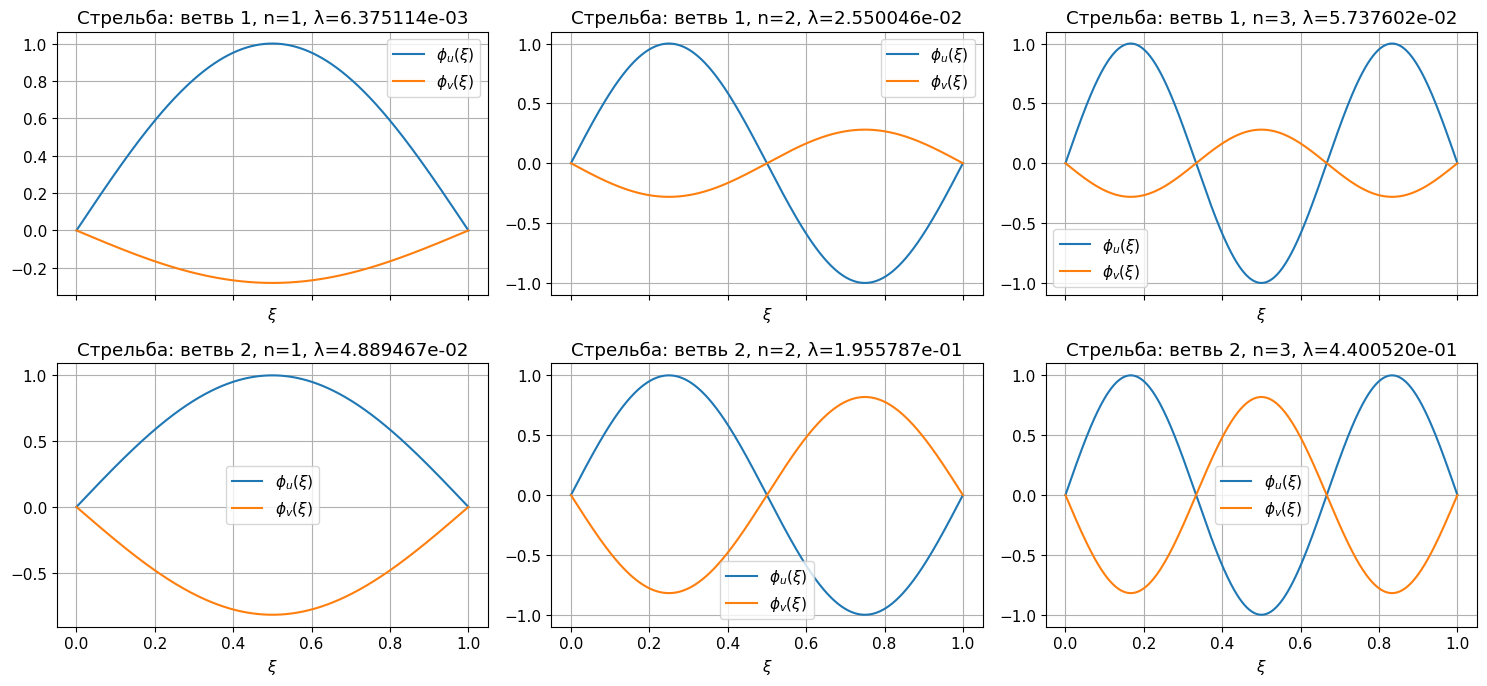

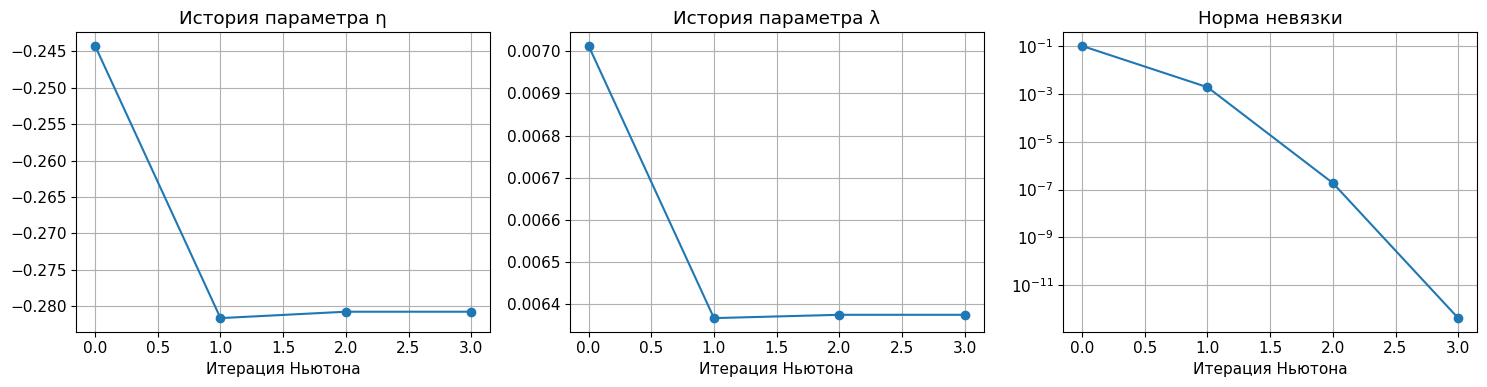

In [4]:
eigen_shoot_results = []

for branch in range(2):
    for n in [1, 2, 3]:
        res = solve_eigen_by_shooting(branch, n, nsteps=5000)
        eigen_shoot_results.append(res)

print(f"{'ветвь':>6} {'n':>4} {'lambda_exact':>16} {'lambda_shoot':>16} {'rel.err':>12} {'X_exact':>12} {'X_shoot':>12} {'ok':>6}")
for r in eigen_shoot_results:
    rel = abs(r["lambda"] - r["lambda_exact"]) / abs(r["lambda_exact"])
    print(f"{r['branch']:6d} {r['n']:4d} {r['lambda_exact']:16.10e} {r['lambda']:16.10e} {rel:12.3e} {r['Xcrit_exact']:12.6f} {r['Xcrit']:12.6f} {str(r['converged']):>6}")

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for ax, r in zip(axes.ravel(), eigen_shoot_results):
    ax.plot(r["xi"], r["phi_u"], label=r"$\phi_u(\xi)$")
    ax.plot(r["xi"], r["phi_v"], label=r"$\phi_v(\xi)$")
    ax.set_title(f"Стрельба: ветвь {r['branch']}, n={r['n']}, λ={r['lambda']:.6e}")
    ax.set_xlabel(r"$\xi$")
    ax.legend()
plt.tight_layout()
plt.show()

sample = eigen_shoot_results[0]
hist_eta = [item["eta"] for item in sample["history"]]
hist_lam = [item["lambda"] for item in sample["history"]]
hist_norm = [item["norm"] for item in sample["history"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(len(hist_eta)), hist_eta, marker="o")
axes[0].set_title("История параметра η")
axes[0].set_xlabel("Итерация Ньютона")

axes[1].plot(range(len(hist_lam)), hist_lam, marker="o")
axes[1].set_title("История параметра λ")
axes[1].set_xlabel("Итерация Ньютона")

axes[2].semilogy(range(len(hist_norm)), hist_norm, marker="o")
axes[2].set_title("Норма невязки")
axes[2].set_xlabel("Итерация Ньютона")

plt.tight_layout()
plt.show()

 ветвь    n     lambda_exact     lambda_shoot        lambda_fd    err_shoot       err_fd
     1    1 6.3751138106e-03 6.3751138106e-03 6.3751136021e-03    9.857e-13    3.271e-08
     1    2 2.5500455242e-02 2.5500455242e-02 2.5500451885e-02    4.272e-14    1.317e-07
     1    3 5.7376024296e-02 5.7376024296e-02 5.7376007307e-02    1.735e-12    2.961e-07
     2    1 4.8894670835e-02 4.8894670835e-02 4.8894669259e-02    1.277e-15    3.225e-08
     2    2 1.9557868334e-01 1.9557868334e-01 1.9557865765e-01    2.408e-12    1.314e-07
     2    3 4.4005203752e-01 4.4005203752e-01 4.4005190723e-01    4.169e-12    2.961e-07


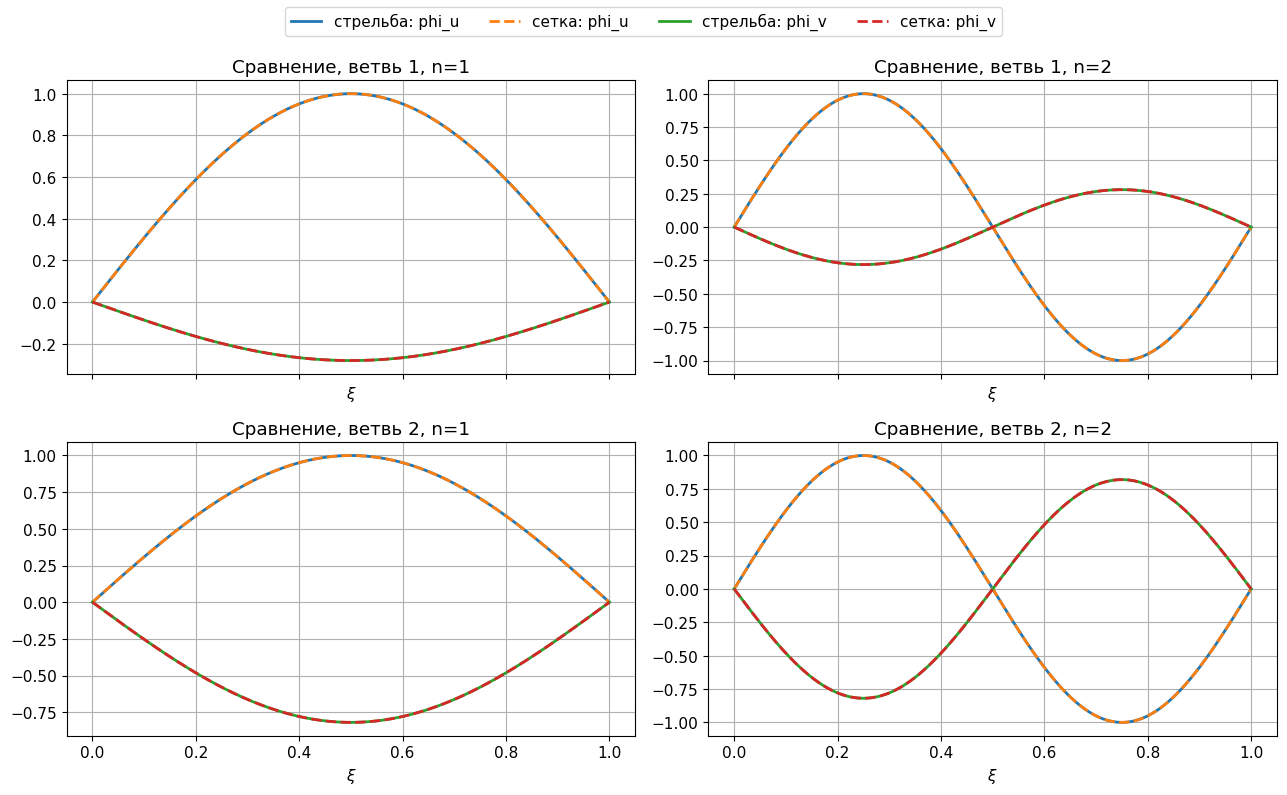

In [12]:
eigen_fd_results = []

for branch in range(2):
    for n in [1, 2, 3]:
        res = solve_eigen_by_fd(branch, n, N=5000)
        eigen_fd_results.append(res)

fd_map = {(r["branch"], r["n"]): r for r in eigen_fd_results}
shoot_map = {(r["branch"], r["n"]): r for r in eigen_shoot_results}

print(f"{'ветвь':>6} {'n':>4} {'lambda_exact':>16} {'lambda_shoot':>16} {'lambda_fd':>16} {'err_shoot':>12} {'err_fd':>12}")
for key in sorted(fd_map.keys()):
    rs = shoot_map[key]
    rf = fd_map[key]
    err_s = abs(rs["lambda"] - rs["lambda_exact"]) / abs(rs["lambda_exact"])
    err_f = abs(rf["lambda"] - rf["lambda_exact"]) / abs(rf["lambda_exact"])
    print(f"{key[0]:6d} {key[1]:4d} {rs['lambda_exact']:16.10e} {rs['lambda']:16.10e} {rf['lambda']:16.10e} {err_s:12.3e} {err_f:12.3e}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
pairs = [(1, 1), (1, 2), (2, 1), (2, 2)]

for ax, key in zip(axes.ravel(), pairs):
    rs = shoot_map[key]
    rf = fd_map[key]

    su = rs["phi_u"]
    fu = rf["phi_u"]
    sv = rs["phi_v"]
    fv = rf["phi_v"]

    sign_u = 1.0 if np.dot(su, fu) >= 0.0 else -1.0
    sign_v = 1.0 if np.dot(sv, fv) >= 0.0 else -1.0

    ax.plot(rs["xi"], su, lw=2, label="стрельба: phi_u")
    ax.plot(rf["xi"], sign_u * fu, "--", lw=2, label="сетка: phi_u")
    ax.plot(rs["xi"], sv, lw=2, label="стрельба: phi_v")
    ax.plot(rf["xi"], sign_v * fv, "--", lw=2, label="сетка: phi_v")
    ax.set_title(f"Сравнение, ветвь {key[0]}, n={key[1]}")
    ax.set_xlabel(r"$\xi$")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## Нелинейная краевая задача

### Метод квазилинеаризации

На сетке строится ньютоновская линеаризация:
\[
D_u \delta u'' + f_u(u^{(k)},v^{(k)})\,\delta u + f_v(u^{(k)},v^{(k)})\,\delta v = -R_u^{(k)},
\]
\[
D_v \delta v'' + g_u(u^{(k)},v^{(k)})\,\delta u + g_v(u^{(k)},v^{(k)})\,\delta v = -R_v^{(k)}.
\]
После аппроксимации центральными разностями получается **блочно-трёхдиагональная** система по внутренним узлам. Она решается блочной прогонкой.

### Метод стрельбы

Поскольку на концах стоят одинаковые граничные условия, для симметричной структуры естественно искать решение на половине отрезка:
\[
u_s(X/2)=0,\qquad v_s(X/2)=0,
\]
где \(s\) — локальная координата от центра к краю. Тогда неизвестными параметрами стрельбы служат
\[
a = u(X/2),\qquad b = v(X/2),
\]
а на краю нужно выполнить
\[
u(X)=2,\qquad v(X)=2.3.
\]
Якобиан по \((a,b)\) вычисляется из расширенной системы чувствительности.

Ниже сначала выполняется решение методом квазилинеаризации для нескольких значений \(X\), а затем для наиболее выраженной структуры запускается метод стрельбы.

X =   50.0
  выбранный старт: модальная инициализация: ветвь=2, n=226, eps=0.08
  сошлось: True
  итераций: 4
  финальная норма невязки: 5.519257e-11
  отклонение от равновесия: 9.300050e-09

X =  100.0
  выбранный старт: модальная инициализация: ветвь=2, n=452, eps=0.08
  сошлось: True
  итераций: 4
  финальная норма невязки: 7.343774e-10
  отклонение от равновесия: 2.173197e-07

X =  150.0
  выбранный старт: модальная инициализация: ветвь=2, n=678, eps=0.03
  сошлось: True
  итераций: 4
  финальная норма невязки: 1.001820e-09
  отклонение от равновесия: 2.064287e-07

X =  200.0
  выбранный старт: модальная инициализация: ветвь=2, n=904, eps=0.08
  сошлось: True
  итераций: 5
  финальная норма невязки: 7.879403e-10
  отклонение от равновесия: 7.750131e-09



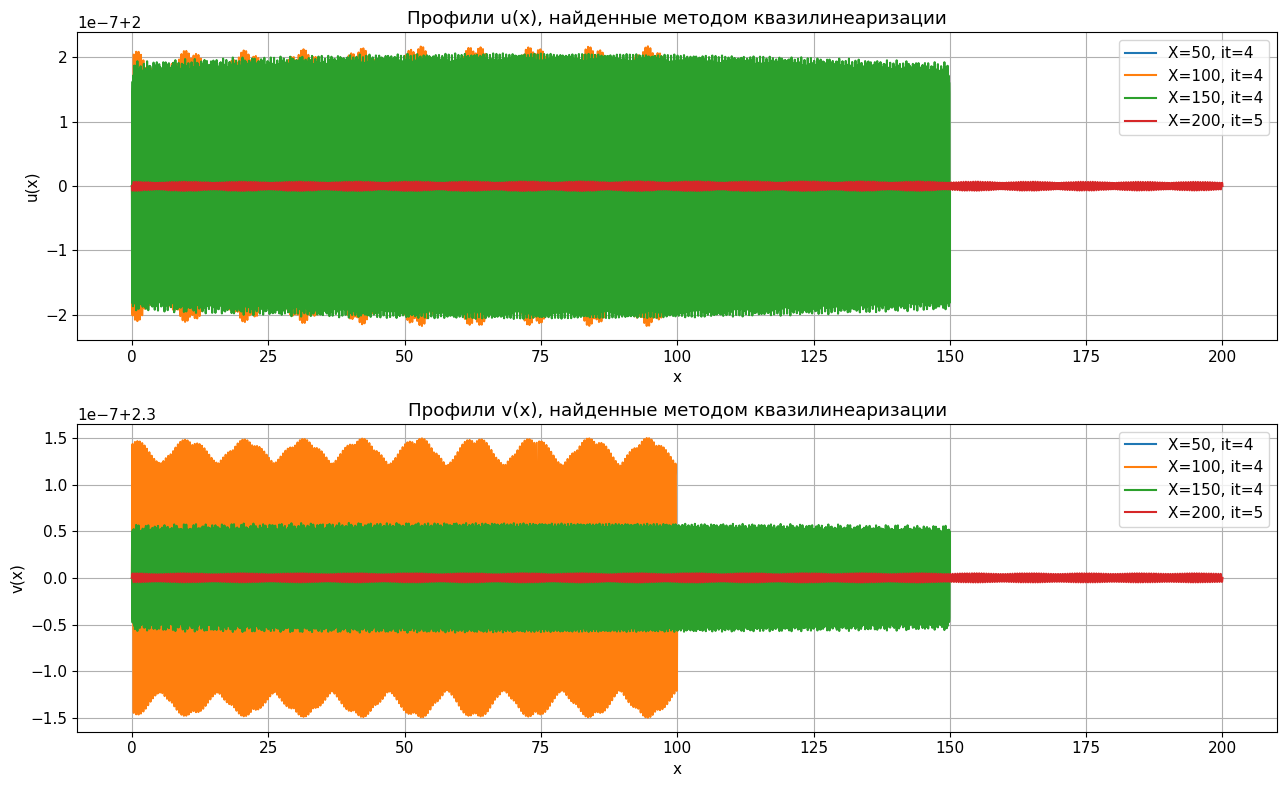

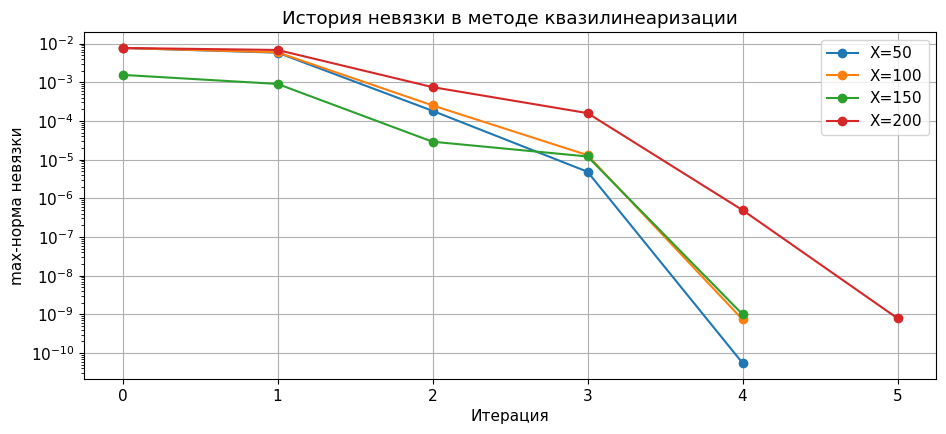

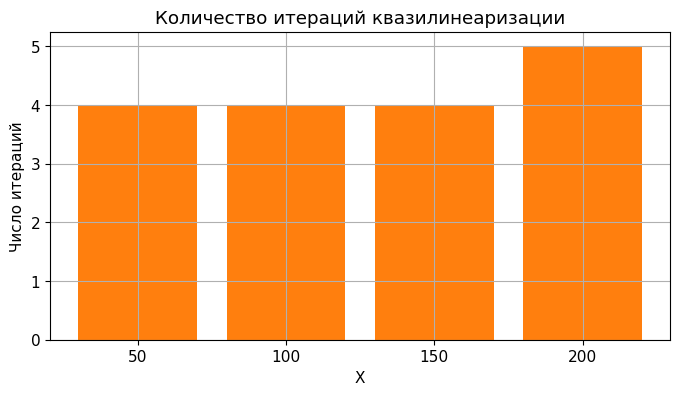

Демонстрационная длина для сравнения методов: X = 100.000000
Отклонение от равновесия: 2.173197e-07
Старт для квазилинеаризации: модальная инициализация: ветвь=2, n=452, eps=0.08


In [9]:
X_values = [50.0, 100.0, 150.0, 200.0]

quasi_results = []
trial_reports = []
continuation = None

for X in X_values:
    best, report = find_quasilinear_solution(X, continuation=continuation, density=32)
    quasi_results.append(best)
    trial_reports.append(report)

    print(f"X = {X:6.1f}")
    print(f"  выбранный старт: {best['label']}")
    print(f"  сошлось: {best['converged']}")
    print(f"  итераций: {best['iterations']}")
    print(f"  финальная норма невязки: {best['final_norm']:.6e}")
    print(f"  отклонение от равновесия: {best['deviation']:.6e}")
    print()

    if best["converged"]:
        continuation = best

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

for res in quasi_results:
    axes[0].plot(res["x"], res["u"], label=f"X={res['x'][-1]:.0f}, it={res['iterations']}")
    axes[1].plot(res["x"], res["v"], label=f"X={res['x'][-1]:.0f}, it={res['iterations']}")

axes[0].set_title("Профили u(x), найденные методом квазилинеаризации")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend()

axes[1].set_title("Профили v(x), найденные методом квазилинеаризации")
axes[1].set_xlabel("x")
axes[1].set_ylabel("v(x)")
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
for res in quasi_results:
    hist = res["residual_history"]
    ax.semilogy(range(len(hist)), hist, marker="o", label=f"X={res['x'][-1]:.0f}")
ax.set_title("История невязки в методе квазилинеаризации")
ax.set_xlabel("Итерация")
ax.set_ylabel("max-норма невязки")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([str(int(res["x"][-1])) for res in quasi_results], [res["iterations"] for res in quasi_results], color="tab:orange")
ax.set_title("Количество итераций квазилинеаризации")
ax.set_xlabel("X")
ax.set_ylabel("Число итераций")
plt.show()

converged_quasi = [res for res in quasi_results if res["converged"]]
if len(converged_quasi) > 0:
    demo_quasi = max(converged_quasi, key=lambda z: z["deviation"])
else:
    demo_quasi = min(quasi_results, key=lambda z: z["final_norm"])

demo_X = float(demo_quasi["x"][-1])
print(f"Демонстрационная длина для сравнения методов: X = {demo_X:.6f}")
print(f"Отклонение от равновесия: {demo_quasi['deviation']:.6e}")
print(f"Старт для квазилинеаризации: {demo_quasi['label']}")

Метод стрельбы для X = 100.000000
  сошлось: True
  итоговые параметры: a = 2.0000000000, b = 2.3000000000
  невязка на границе: [ 0. -0.]


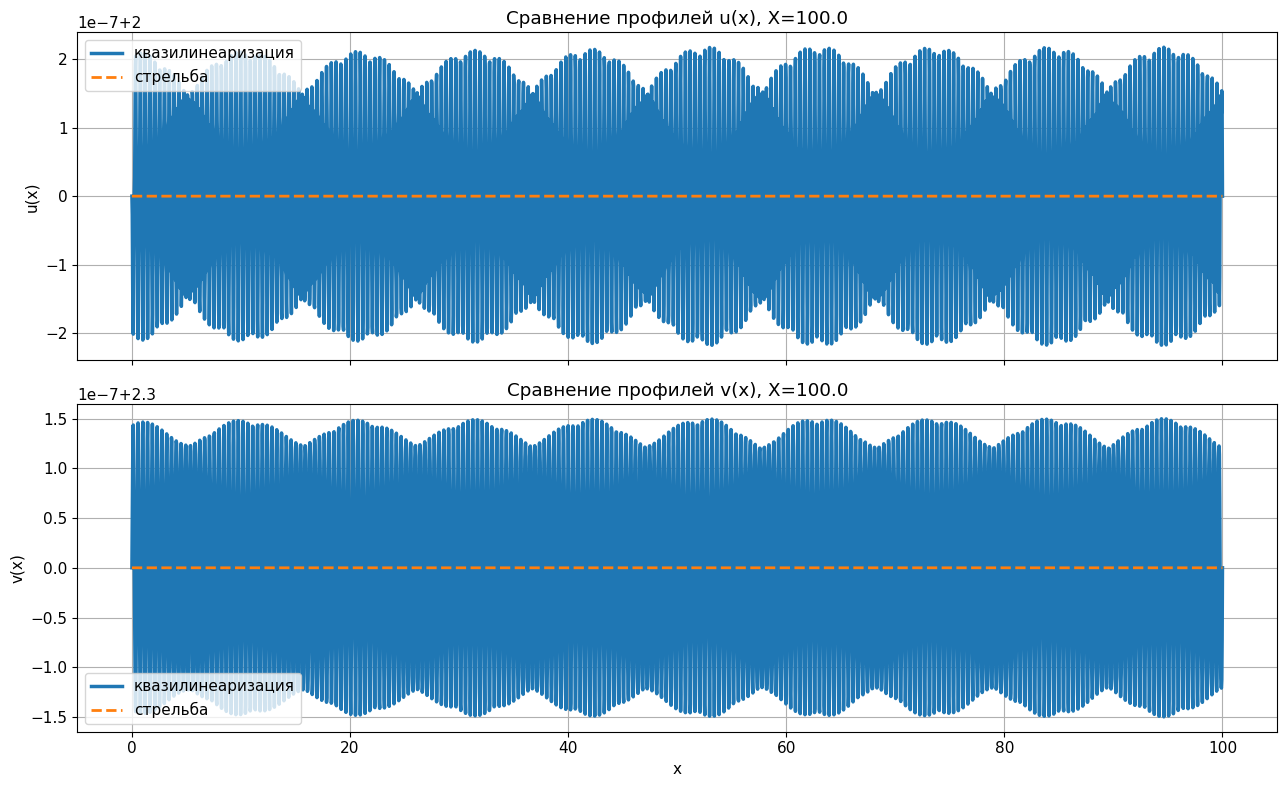

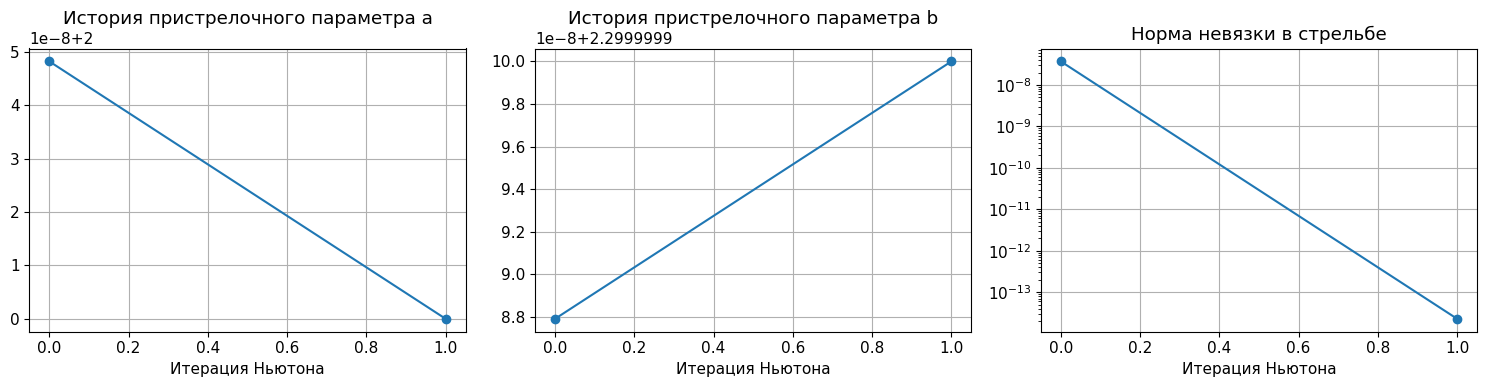

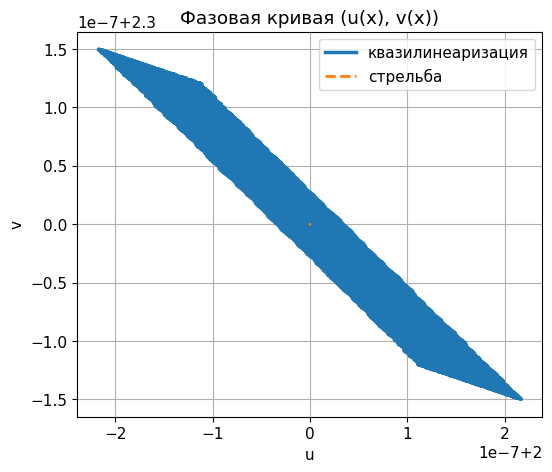

Максимальное отличие методов по u(x): 2.173197e-07
Максимальное отличие методов по v(x): 1.497883e-07


In [10]:
mid = len(demo_quasi["x"]) // 2
a0 = float(demo_quasi["u"][mid])
b0 = float(demo_quasi["v"][mid])

shoot_res = shooting_symmetric_solution(demo_X, a0, b0, nsteps=max(8000, int(120 * demo_X)))

print(f"Метод стрельбы для X = {demo_X:.6f}")
print(f"  сошлось: {shoot_res['converged']}")
print(f"  итоговые параметры: a = {shoot_res['params'][0]:.10f}, b = {shoot_res['params'][1]:.10f}")
print(f"  невязка на границе: {shoot_res['residual']}")

u_shoot_on_quasi = np.interp(demo_quasi["x"], shoot_res["x"], shoot_res["u"])
v_shoot_on_quasi = np.interp(demo_quasi["x"], shoot_res["x"], shoot_res["v"])

diff_u = np.max(np.abs(demo_quasi["u"] - u_shoot_on_quasi))
diff_v = np.max(np.abs(demo_quasi["v"] - v_shoot_on_quasi))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(demo_quasi["x"], demo_quasi["u"], lw=2.5, label="квазилинеаризация")
axes[0].plot(shoot_res["x"], shoot_res["u"], "--", lw=2, label="стрельба")
axes[0].set_title(f"Сравнение профилей u(x), X={demo_X:.1f}")
axes[0].set_ylabel("u(x)")
axes[0].legend()

axes[1].plot(demo_quasi["x"], demo_quasi["v"], lw=2.5, label="квазилинеаризация")
axes[1].plot(shoot_res["x"], shoot_res["v"], "--", lw=2, label="стрельба")
axes[1].set_title(f"Сравнение профилей v(x), X={demo_X:.1f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("v(x)")
axes[1].legend()

plt.tight_layout()
plt.show()

hist_a = [item["a"] for item in shoot_res["history"]]
hist_b = [item["b"] for item in shoot_res["history"]]
hist_norm = [item["norm"] for item in shoot_res["history"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(len(hist_a)), hist_a, marker="o")
axes[0].set_title("История пристрелочного параметра a")
axes[0].set_xlabel("Итерация Ньютона")

axes[1].plot(range(len(hist_b)), hist_b, marker="o")
axes[1].set_title("История пристрелочного параметра b")
axes[1].set_xlabel("Итерация Ньютона")

axes[2].semilogy(range(len(hist_norm)), hist_norm, marker="o")
axes[2].set_title("Норма невязки в стрельбе")
axes[2].set_xlabel("Итерация Ньютона")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(demo_quasi["u"], demo_quasi["v"], lw=2.5, label="квазилинеаризация")
ax.plot(shoot_res["u"], shoot_res["v"], "--", lw=2, label="стрельба")
ax.set_title("Фазовая кривая (u(x), v(x))")
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.legend()
plt.show()

print(f"Максимальное отличие методов по u(x): {diff_u:.6e}")
print(f"Максимальное отличие методов по v(x): {diff_v:.6e}")

In [11]:
max_rel_err_shoot = max(abs(r["lambda"] - r["lambda_exact"]) / abs(r["lambda_exact"]) for r in eigen_shoot_results)
max_rel_err_fd = max(abs(r["lambda"] - r["lambda_exact"]) / abs(r["lambda_exact"]) for r in eigen_fd_results)

print("Итоговая сводка")
print("--------------")
print(f"Максимальная относительная ошибка по λ в спектральной задаче, стрельба: {max_rel_err_shoot:.6e}")
print(f"Максимальная относительная ошибка по λ в спектральной задаче, сетка+доп.вектор: {max_rel_err_fd:.6e}")
print(f"Демонстрационная длина в нелинейной задаче: X = {demo_X:.6f}")
print(f"Квазилинеаризация: итераций = {demo_quasi['iterations']}, final_norm = {demo_quasi['final_norm']:.6e}")
print(f"Стрельба: итераций = {max(0, len(shoot_res['history']) - 1)}, final_boundary_res = {max_abs(shoot_res['residual']):.6e}")
print(f"Согласование методов: ||u_q - u_s||_inf = {diff_u:.6e}, ||v_q - v_s||_inf = {diff_v:.6e}")

print()
print("Использованные наблюдения по диапазону X in [50, 200]:")
for branch in range(2):
    ns, Xs, step = critical_lengths_for_branch(branch, 50.0, 200.0)
    print(f"  ветвь {branch+1}: число критических длин = {len(Xs)}, шаг ≈ {step:.6f}, первый X ≈ {Xs[0]:.6f}, последний X ≈ {Xs[-1]:.6f}")

Итоговая сводка
--------------
Максимальная относительная ошибка по λ в спектральной задаче, стрельба: 4.168647e-12
Максимальная относительная ошибка по λ в спектральной задаче, сетка+доп.вектор: 1.510645e-05
Демонстрационная длина в нелинейной задаче: X = 100.000000
Квазилинеаризация: итераций = 4, final_norm = 7.343774e-10
Стрельба: итераций = 1, final_boundary_res = 2.264855e-14
Согласование методов: ||u_q - u_s||_inf = 2.173197e-07, ||v_q - v_s||_inf = 1.497883e-07

Использованные наблюдения по диапазону X in [50, 200]:
  ветвь 1: число критических длин = 1878, шаг ≈ 0.079844, первый X ≈ 50.062382, последний X ≈ 199.930152
  ветвь 2: число критических длин = 678, шаг ≈ 0.221121, первый X ≈ 50.194556, последний X ≈ 199.893740


## Выводы

1. **Метод стрельбы** даёт очень точные результаты и хорошо подходит для краевых задач, если удаётся построить разумное начальное приближение для пристрелочных параметров. Для рассматриваемой задачи удобно использовать симметрию и вести стрельбу от центра отрезка. Интегрирование **расширенной системы** позволяет вычислять якобиан без численного дифференцирования.

2. **Метод квазилинеаризации** оказался естественным и устойчивым инструментом для нелинейной краевой задачи на длинных интервалах. После дискретизации возникает **блочно-трёхдиагональная** система, поэтому использование **прогонки** даёт эффективную и прозрачную реализацию.

3. Для **задачи поиска собственных значений** обе адаптации работают корректно:
   - стрельба — через неизвестные \((\eta,\lambda)\) и расширенную систему;
   - сеточный подход — через метод **дополненного вектора** с нормировкой и блочной прогонкой.

4. Линеаризованная спектральная задача полезна не только сама по себе: найденные собственные значения и собственные функции дают хорошие стартовые приближения для поиска нелинейных структур.

5. На длинных отрезках \(X\in[50,200]\) критические длины располагаются **густо**, поэтому вблизи каждого выбранного \(X\) естественно ожидать наличие близких линейных мод. Это объясняет, почему спектральный анализ является важным предварительным этапом перед решением полной нелинейной задачи.

6. Практически:
   - если нужен **точный профиль конкретной симметричной структуры**, удобно использовать стрельбу;
   - если требуется **устойчивое получение решения на сетке** и дальнейшее продолжение по параметру \(X\), то предпочтительнее квазилинеаризация.

Ноутбук устроен так, чтобы его можно было запускать сверху вниз как полноценный отчёт.